Slope without COVID:  0.056617647058823384
Slope with Covid:  0.045714285714285596

RMSE Polynomial: 9.9653
RMSE Linear: 10.0458
RMSE Linear No Covid: 10.0555
RMSE_Cubic: 0.0000

Condition number (Polynomial): 47604184081.314445
Condition number (Linear): 464.17077795134537
Condition number (Linear No COVID): 266.0109466385601

Big O for Cubic Spline Interpolation: O(n^2)
Big O for Linear Least Squares: O(n)
Big O for Polynomial fit of Degree 4: O(n)


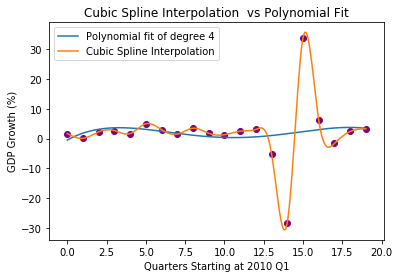

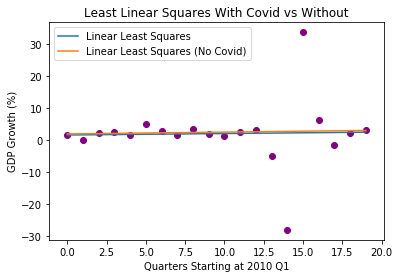

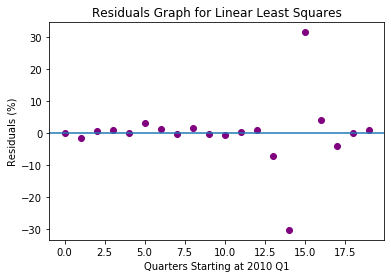

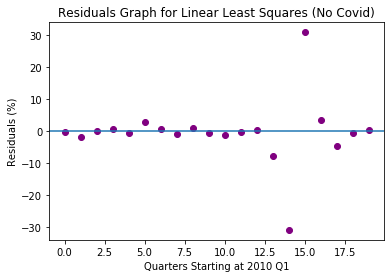

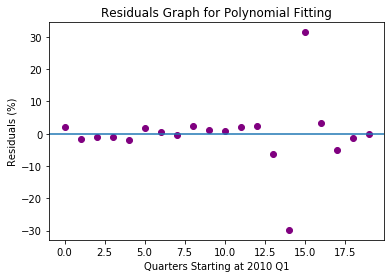

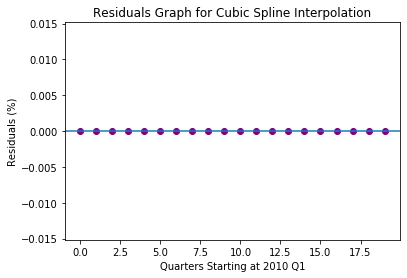

In [45]:
import numpy as np
import matplotlib.pyplot as plt

def setup_tridiagonal_matrix(x, y): #constructs tridiagonal matrix

    n = len(x)

    h = np.diff(x)  
    A = np.zeros(n - 2) #subdiagonal
    B = np.zeros(n - 2) #maindiagonal
    C = np.zeros(n - 2) #superdiagonal
    D = np.zeros(n - 2) #righthand side vector

    for i in range(1, n - 1):

        A[i - 1] = h[i-1]                                                          
        B[i - 1] = 2*(h[i-1]+h[i])                                                
        C[i - 1] = h[i]                                                           
        D[i - 1] = 6 * (((y[i+1]-y[i])/h[i]) - ((y[i]-y[i-1])/h[i-1]))            

    return A, B, C, D

def thomas_algorithm(a, b, c, d): #solves triagonal matrix using thomas algorithm
    n = len(b)
    b=b.copy()
    d=d.copy()
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

def evaluate_spline(x, y, M, xval): #evaluates cubic spline at a point. uses second derivative to ensure continuity
    for i in range(len(x) - 1):
        if x[i] <= xval <= x[i+1]:
            h = x[i+1] - x[i]
            first = M[i] / (6*h) * ((x[i+1] - xval)**3)
            second = M[i+1] / (6*h) * ((xval - x[i])**3)
            third = ((y[i] / h) - ((M[i] * h / 6))) * (x[i+1] - xval)
            fourth = ((y[i+1] / h) - ((M[i+1] * h / 6))) * (xval - x[i])
            
            S = first + second + third + fourth
            return S

y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])
x = np.arange(len(y))
x_full = np.linspace(x[0], x[-1], 300)

A, B, C, D = setup_tridiagonal_matrix(x, y) #build spline system
D2 = thomas_algorithm(A, B, C, D) #solve spline system

M= np.zeros(len(x))
M[1:-1] = D2

yvals= [] #evaluating spline to plot
for j in x_full: 
    yvals.append(evaluate_spline(x ,y ,M ,j))

x_no_covid = np.delete(x, np.arange(13, 18)) #removing covid quarters
y_no_covid = np.delete(y, np.arange(13, 18))

B = np.vstack([x_no_covid, np.ones(len(x_no_covid))]).T #solving least linear squares without covid
BT_V = np.dot(B.T, B)
BT_y = np.dot(B.T, y_no_covid)
m_no_covid, c_no_covid, = np.linalg.solve(BT_V, BT_y)

A = np.vstack([x, np.ones(len(x))]).T #solving least linear squares with covid
AT_V = np.dot(A.T, A)
AT_y = np.dot(A.T, y)
m, c = np.linalg.solve(AT_V, AT_y)
print('Slope without COVID: ', m_no_covid)
print('Slope with Covid: ', m)


degree = 4
V = np.vander(x, N=degree+1, increasing=True)
VT_V = np.dot(V.T, V)
VT_y = np.dot(V.T, y)
    
a = np.linalg.solve(VT_V, VT_y)
V_full = np.vander(x_full, N=degree+1, increasing=True) #chat gpt helped me here. Previously I wasn't plotting the curve using all 300 values
y_pred = V_full@a

spline = []
for k in x:
    spline.append(evaluate_spline(x ,y ,M ,k))

residuals = y - (m*x +c) #computing residuals for each method
residuals_no_covid = y - (m_no_covid*x +c_no_covid)
residuals_poly = y - (V@a)
residuals_cubic = y-spline

rmse_poly = np.sqrt(np.mean(residuals_poly**2)) #computing rmse for each method
rmse_linear = np.sqrt(np.mean(residuals**2)) 
rmse_linear_no_covid = np.sqrt(np.mean(residuals_no_covid**2))
rmse_cubic = np.sqrt(np.mean(residuals_cubic**2))

print(f'\nRMSE Polynomial: {rmse_poly:.4f}') 
print(f'RMSE Linear: {rmse_linear:.4f}')
print(f'RMSE Linear No Covid: {rmse_linear_no_covid:.4f}')
print(f'RMSE_Cubic: {rmse_cubic:.4f}')

print('\nCondition number (Polynomial):', np.linalg.cond(VT_V)) #chatgpt helped me figure out how to find the condition number
print('Condition number (Linear):', np.linalg.cond(AT_V)) #finding condition number for each method
print('Condition number (Linear No COVID):', np.linalg.cond(BT_V))

print('\nBig O for Cubic Spline Interpolation: O(n^2)')
print('Big O for Linear Least Squares: O(n)')
print('Big O for Polynomial fit of Degree 4: O(n)')

plt.figure(1)
plt.plot(x_full, y_pred, label=f'Polynomial fit of degree 4')
plt.plot(x_full, yvals, label = 'Cubic Spline Interpolation')
plt.scatter(x,y, color = 'purple')
plt.xlabel('Quarters Starting at 2010 Q1')
plt.ylabel('GDP Growth (%)')
plt.title('Cubic Spline Interpolation  vs Polynomial Fit')
plt.legend()

plt.figure(2)
plt.plot(x_full, m*x_full +c, label = 'Linear Least Squares')
plt.plot(x_full, m_no_covid*x_full + c_no_covid, label = 'Linear Least Squares (No Covid)')
plt.scatter(x,y, color = 'purple')
plt.xlabel('Quarters Starting at 2010 Q1')
plt.ylabel('GDP Growth (%)')
plt.title('Least Linear Squares With Covid vs Without')
plt.legend()

plt.figure(3)
plt.scatter(x, residuals, color = 'purple')
plt.xlabel('Quarters Starting at 2010 Q1')
plt.ylabel('Residuals (%)')
plt.title('Residuals Graph for Linear Least Squares')
plt.axhline(0)

plt.figure(4)
plt.scatter(x, residuals_no_covid, color = 'purple')
plt.xlabel('Quarters Starting at 2010 Q1')
plt.ylabel('Residuals (%)')
plt.title('Residuals Graph for Linear Least Squares (No Covid)')
plt.axhline(0)

plt.figure(5)
plt.scatter(x, residuals_poly, color = 'purple')
plt.xlabel('Quarters Starting at 2010 Q1')
plt.ylabel('Residuals (%)')
plt.title('Residuals Graph for Polynomial Fitting')
plt.axhline(0)

plt.figure(6)
plt.scatter(x, residuals_cubic, color = 'purple')
plt.xlabel('Quarters Starting at 2010 Q1')
plt.ylabel('Residuals (%)')
plt.title('Residuals Graph for Cubic Spline Interpolation')
plt.axhline(0)
plt.show()

In [3]:
"""
We are analyzing a dataset from the U.S. Bureau of Economic Analysis that showcases GDP growth in percent from 2010 to 2023 for different quarters. The data is not complete and does not showcase GDP growth for every quarter for the years being analyzed. For this reason we have to employ different methods to account for this loss of data. The three methods we will be using are cubic spline interpolation, polynomial fitting, and least squares comparison. 
Cubic spline interpolation is a method that constructs a piecewise cubic function that passes  through all points on the graph. This method also ensures that the first and second derivatives are continuous in order to make the graph as smooth as possible. In our system of equations there are (n-2) unknowns that we are solving for. The boundary conditions are M(0) = 0 and M(n-1) = 0. These conditions lead to a tridiagonal system of equations that are obtained by enforcing continuity at each of the interior knots for the first and second derivative.  After we evaluate the spline across all of the quarters and graph it, the plot displays a very smooth curve. It is reasonable everywhere except for extreme values that occur due to Covid. Because cubic spline interpolation goes through every data point, it makes it more susceptible to outliers. Although the Runge phenomenon is mainly associated with higher-degree polynomial interpolation, the graph still can experience local distortions near outliers due to having to pass through all points. I do not think the data is noisy enough to justify suggesting weighted least squares over smoothing the spline. 
Polynomial fitting is a method that approximates data with a polynomial function. It raises variables to a higher degree and then uses linear regression of those variables to find coefficients. Polynomial fitting is better than cubic spline interpolation at determining the overall trend because it is skewed less by outliers like cubic spline interpolation is. This demonstrates a trade-off between interpolation and numerical stability. On the other hand, cubic spline interpolation is better at reproducing specific points because it goes through every point.
The final method we are implementing is linear least squares. This method finds the best fitting solution to a system of equations. The slope without Covid being a factor is approximately 0.0566. The linear trend displays overall growth which is a reasonable approximation for the entire trend of the data. The slope indicates positive GDP growth rate per quarter for the time period. A downside to linear models is that they cannot fully exhibit outlying factors such as Covid or business cycles. Due to this, they do not accurately reflect the economic nuances required for a precise analysis. This model assumes that errors are normally distributed, the relationship between input and output is linear, errors are independent from one another, and a constant variance of residuals. 
Big O notation helps describe time and space complexity of an algorithm as it experiences more input. It is important in understanding the efficiency and scalability of an algorithm. The cubic spline interpolation has a Big O notation of O(n^2) while linear least squares and polynomial fitting has a Big O notation of O(n). As a result of the data being smaller, these differences in complexity do not significantly impact the method of choice. A downside of cubic spline interpolation is how susceptible it is to outliers. The RMSE for cubic spline interpolation is approximately zero, because it goes through all points. Nevertheless, outliers cause this to be less of an indicator on the performance of the approximation. Despite these considerations, I recommend that a policymaker should use the cubic spline for the situation described. Although the spline is affected by outliers, due to the piecewise function going through all points, the outliers are limited in their effects on local regions. Furthermore, the graph for cubic spline interpolation is smoother than the graphs for the other methods. 
When analyzing over a longer period of time, polynomial fit is the best option. This is because it is less influenced by outliers. When analyzing over a shorter period of time, cubic spline interpolation is the best for reasons stated earlier. Finally, when analyzing data with a lot of noise, linear least squares are the best. I learned that a major downside of the cubic interpolation was that it is required to go through the outliers as well; that was something I honestly did not think of when I first started. I also learned that a major limitation of linear least squares is that it's linear; the graph is not very complex and therefore cannot showcase the complexities that the data may show. Finally, I learned that a limitation that polynomial fit has is that it is not very accurate when zooming in on specific quarters that it estimated; it is better for long term examination.  
#chatgpt helped me with typos and tweaking the writeup
"""

'\nkdjdjalkj\n'